In [1]:
import os
import glob
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Suppress verbose TF logging for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ==========================================
# 1. HYPERPARAMETERS & CONFIGURATION
# ==========================================
DATA_ROOT = "/kaggle/input/datasets/balraj98/deepglobe-road-extraction-dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
SAVE_PATH = "/kaggle/working/dlinknet_resnet50.keras"

EPOCHS = 15         
BATCH_SIZE = 4
CROP_SIZE = 512
LEARNING_RATE = 1e-4 # Lower LR to prevent destroying pre-trained ResNet weights

2026-06-26 11:51:37.867778: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782474698.035689      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782474698.085314      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782474698.476935      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474698.476973      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474698.476975      24 computation_placer.cc:177] computation placer alr

In [2]:
def process_path(img_path):
    """Loads image and mask keeping them in native uint8 to prevent CPU RAM explosion."""
    mask_path = tf.strings.regex_replace(img_path, "_sat.jpg", "_mask.png")
    
    # Load as native uint8 (1 byte per pixel)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    
    return img, mask

def augment_and_crop(img, mask):
    """Crops in uint8 format, then applies Late Casting to float32."""
    # 1. Concat and Crop while still in memory-efficient uint8
    combined = tf.concat([img, mask], axis=-1)
    cropped = tf.image.random_crop(combined, size=[CROP_SIZE, CROP_SIZE, 4])
    
    img = cropped[..., :3]
    mask = cropped[..., 3:]
    
    # 2. Basic spatial augmentation
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
        
    # 3. LATE CASTING: Convert the 256x256 crop to float32
    # This reduces the float32 footprint from 16.7 MB to 262 KB per image
    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    
    return img, mask

In [3]:
def build_dataset(paths, training=True):
    dataset = tf.data.Dataset.from_tensor_slices(paths)
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        dataset = dataset.cache()
        dataset = dataset.shuffle(buffer_size=500)
        dataset = dataset.map(augment_and_crop, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        # For validation during training, we do a deterministic center crop
        def center_crop(img, mask):
            # 1. Spatial Alignment
            img = tf.image.resize_with_crop_or_pad(img, CROP_SIZE, CROP_SIZE)
            mask = tf.image.resize_with_crop_or_pad(mask, CROP_SIZE, CROP_SIZE)
            
            # 2. Late Casting & Normalization
            img = tf.cast(img, tf.float32) / 255.0
            mask = tf.cast(mask, tf.float32) / 255.0
            mask = tf.where(mask > 0.5, 1.0, 0.0)
            
            return img, mask
        dataset = dataset.map(center_crop, num_parallel_calls=tf.data.AUTOTUNE)
        
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [4]:
# ==========================================
# 3. KERAS FUNCTIONAL API ARCHITECTURE
# ==========================================
def double_conv_block(x, out_channels):
    """Standard sequential convolution with BN and ReLU."""
    x = tf.keras.layers.Conv2D(out_channels, kernel_size=(3, 3), padding='same')(x)

    x = tf.keras.layers.GroupNormalization(groups=32, axis=-1)(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(out_channels, kernel_size=(3, 3), padding='same')(x)
    
    x = tf.keras.layers.GroupNormalization(groups=32, axis=-1)(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x

def dilated_conv_block(x, channels, dilation):
    """Atrous convolution for receptive field expansion."""
    x = tf.keras.layers.Conv2D(
        channels, kernel_size=(3, 3), padding='same', dilation_rate=(dilation, dilation)
    )(x)
   # The number of channels in the layer must be divisible by the number of groups.
# Since your depths are 64, 128, 256, 512, groups=32 divides perfectly into all of them.
    x = tf.keras.layers.GroupNormalization(groups=32, axis=-1)(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x

def build_dlinknet_resnet50(input_shape=(None, None, 3)):
    """
    Constructs the Dilated U-Net using a pre-trained ResNet50 backbone.
    Dynamic input shapes allow full 1024x1024 inference during evaluation.
    """
    inputs = tf.keras.Input(shape=input_shape)
    
    # 1. Pre-trained ResNet50 Encoder (Using ImageNet weights)
    resnet = tf.keras.applications.ResNet50(
        include_top=False, 
        weights='imagenet', 
        input_tensor=inputs
    )
    
    # Extract skip connections at exact resolution drops
    # e1: 1/2 res  | e2: 1/4 res  | e3: 1/8 res   | e4: 1/16 res
    e1 = resnet.get_layer('conv1_relu').output          # 64 channels
    e2 = resnet.get_layer('conv2_block3_out').output    # 256 channels
    e3 = resnet.get_layer('conv3_block4_out').output    # 512 channels
    e4 = resnet.get_layer('conv4_block6_out').output    # 1024 channels

    # 2. Cascaded Dilated Bottleneck
    # Connects to 1/16 resolution map, extracting global context
    b1 = dilated_conv_block(e4, 1024, dilation=1)
    b2 = dilated_conv_block(b1, 1024, dilation=2)
    b4 = dilated_conv_block(b2, 1024, dilation=4)
    b8 = dilated_conv_block(b4, 1024, dilation=8)
    bottleneck_out = tf.keras.layers.Add()([e4, b1, b2, b4, b8])

    # 3. U-Net Decoder (with channel math corrected for ResNet50)
    u4 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(bottleneck_out)
    c4 = tf.keras.layers.Concatenate()([u4, e3])
    d4 = double_conv_block(c4, 512)

    u3 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(d4)
    c3 = tf.keras.layers.Concatenate()([u3, e2])
    d3 = double_conv_block(c3, 256)

    u2 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d3)
    c2 = tf.keras.layers.Concatenate()([u2, e1])
    d2 = double_conv_block(c2, 64)

    # Final upsample back to original input resolution (1/1)
    u1 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d2)
    d1 = double_conv_block(u1, 64)

    # Output projection to binary probability
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid', dtype=tf.float32)(d1)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="DLinkNet_ResNet50")

In [5]:
import numpy as np

def predict_roads(model, image_tensor):
    """
    Executes D4 Test-Time Augmentation (8 isometric transformations).
    Calculates the forward pass, applies the exact geometric inverse to the 
    prediction mask, and returns the mean probability tensor.
    
    Args:
        model: The compiled Keras architecture.
        image_tensor: NumPy array of shape (1, 1024, 1024, 3)
    Returns:
        averaged_mask: NumPy array of shape (1, 1024, 1024, 1)
    """
    preds = []
    
    # Iterate through the D4 Group: 2 Flips * 4 Rotations = 8 States
    for flip in [False, True]:
        # Forward Flip
        img_flip = np.flip(image_tensor, axis=2) if flip else image_tensor
        
        for k in range(4):
            # Forward Rotate (Axes 1 and 2 represent H and W in a BHWC tensor)
            img_aug = np.rot90(img_flip, k=k, axes=(1, 2))
            
            # Network Forward Pass
            # We use model(x, training=False) to bypass the predict() memory leak
            pred_aug = model(img_aug, training=False).numpy()
            
            # Inverse Rotate: The mathematical inverse of rot(k) is rot(-k)
            pred_unrot = np.rot90(pred_aug, k=-k, axes=(1, 2))
            
            # Inverse Flip: Re-flip across the width axis
            pred_unflip = np.flip(pred_unrot, axis=2) if flip else pred_unrot
            
            preds.append(pred_unflip)
            
    # Calculate the mean probability across all 8 spatial inferences
    averaged_mask = np.mean(preds, axis=0)
    return averaged_mask

In [6]:
import cv2
import tensorflow as tf

def evaluate_full_resolution(model, val_paths):
    """
    Bypasses the cropped validation loader to evaluate native 1024x1024 tensors,
    utilizing D4 Test-Time Augmentation to maximize topological certainty.
    """
    print("\n--- Commencing Full-Resolution (1024x1024) Evaluation with D4 TTA ---")
    iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='eval_iou')
    
    for i, path in enumerate(val_paths):
        # Progress tracking for the sequential loop
        if i % 10 == 0 and i > 0:
            print(f"Processed {i}/{len(val_paths)} validation images...")

        # 1. Load native 1024x1024 image
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        x = np.expand_dims(img, axis=0).astype(np.float32) / 255.0
        
        # 2. Load native 1024x1024 mask
        mask_path = path.replace("_sat.jpg", "_mask.png")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        y = np.expand_dims(mask, axis=(0, -1)).astype(np.float32) / 255.0
        y = (y > 0.5).astype(np.float32)
        
        # 3. D4 Test-Time Augmentation Inference
        preds = predict_roads(model, x)
        
        # 4. Update Metric
        iou_metric.update_state(y, preds)

    final_iou = iou_metric.result().numpy()
    print("--------------------------------------------------------------")
    print(f"Global Full-Resolution IoU (with D4 TTA): {final_iou:.4f}")
    print("--------------------------------------------------------------")
    return final_iou

In [7]:


@tf.keras.utils.register_keras_serializable()
class BCEDiceLoss(tf.keras.losses.Loss):
    def __init__(self, bce_weight=1.0, dice_weight=1.0, smooth=1e-6, name='bce_dice_loss'):
        super().__init__(name=name)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        # Initialize the standard BCE object to handle numerical stability under the hood
        self.bce = tf.keras.losses.BinaryCrossentropy()

    def call(self, y_true, y_pred):
        # 1. Compute Standard BCE
        bce_loss = self.bce(y_true, y_pred)
        
        # 2. Compute Dice Loss
        # Flatten the tensors to compute the global intersection for the batch
        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        total_area = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
        
        dice_coeff = (2.0 * intersection + self.smooth) / (total_area + self.smooth)
        dice_loss = 1.0 - dice_coeff
        
        # 3. Combine
        return (self.bce_weight * bce_loss) + (self.dice_weight * dice_loss)

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, val_paths, num_samples=4):
    """
    Bypasses the cropped dataloader to evaluate and plot native 1024x1024 tensors.
    Renders Input, Ground Truth, Prediction, and Red Overlay.
    """
    print(f"\n--- Generating {num_samples} Full-Resolution (1024x1024) Visualizations ---")
    
    # Restrict to the requested number of samples
    sample_paths = val_paths[:num_samples]
    plot_count = len(sample_paths)
    
    fig, axes = plt.subplots(plot_count, 4, figsize=(20, 5 * plot_count))
    if plot_count == 1:
        axes = np.expand_dims(axes, 0)
        
    for i, path in enumerate(sample_paths):
        # 1. Load native 1024x1024 image
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        x = np.expand_dims(img, axis=0).astype(np.float32) / 255.0
        
        # 2. Load native 1024x1024 mask
        mask_path = path.replace("_sat.jpg", "_mask.png")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        true_mask = (mask > 127).astype(np.float32)
        
        # 3. Forward pass on dynamic shape
        preds = predict_roads(model,x)
        pred_mask = preds.squeeze()
        binary_pred = (pred_mask > 0.5).astype(np.float32)
        
        # 4. Plotting
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image (1024x1024)")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(binary_pred, cmap='gray')
        axes[i, 2].set_title("Predicted Network")
        axes[i, 2].axis('off')
        
        # 5. Red Overlay Computation
        mask_3d = np.expand_dims(binary_pred, axis=-1)
        red_color = np.array([1.0, 0.0, 0.0], dtype=np.float32)
        alpha = 0.5
        
        # Normalize original image for display blending
        display_img = img.astype(np.float32) / 255.0 
        overlay = display_img * (1.0 - mask_3d * alpha) + red_color * mask_3d * alpha
        overlay = np.clip(overlay, 0.0, 1.0)
        
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Prediction Overlay")
        axes[i, 3].axis('off')
        
    plt.tight_layout()
    plt.show()

Initializing File Paths...
Building Data Pipelines...


I0000 00:00:1782474711.982345      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Compiling Architecture...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Commencing Training Phase...

--- Commencing Full-Resolution (1024x1024) Evaluation with D4 TTA ---


I0000 00:00:1782474726.318299      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


Processed 10/1246 validation images...
Processed 20/1246 validation images...
Processed 30/1246 validation images...
Processed 40/1246 validation images...
Processed 50/1246 validation images...
Processed 60/1246 validation images...
Processed 70/1246 validation images...
Processed 80/1246 validation images...
Processed 90/1246 validation images...
Processed 100/1246 validation images...
Processed 110/1246 validation images...
Processed 120/1246 validation images...
Processed 130/1246 validation images...
Processed 140/1246 validation images...
Processed 150/1246 validation images...
Processed 160/1246 validation images...
Processed 170/1246 validation images...
Processed 180/1246 validation images...
Processed 190/1246 validation images...
Processed 200/1246 validation images...
Processed 210/1246 validation images...
Processed 220/1246 validation images...
Processed 230/1246 validation images...
Processed 240/1246 validation images...
Processed 250/1246 validation images...
Processed

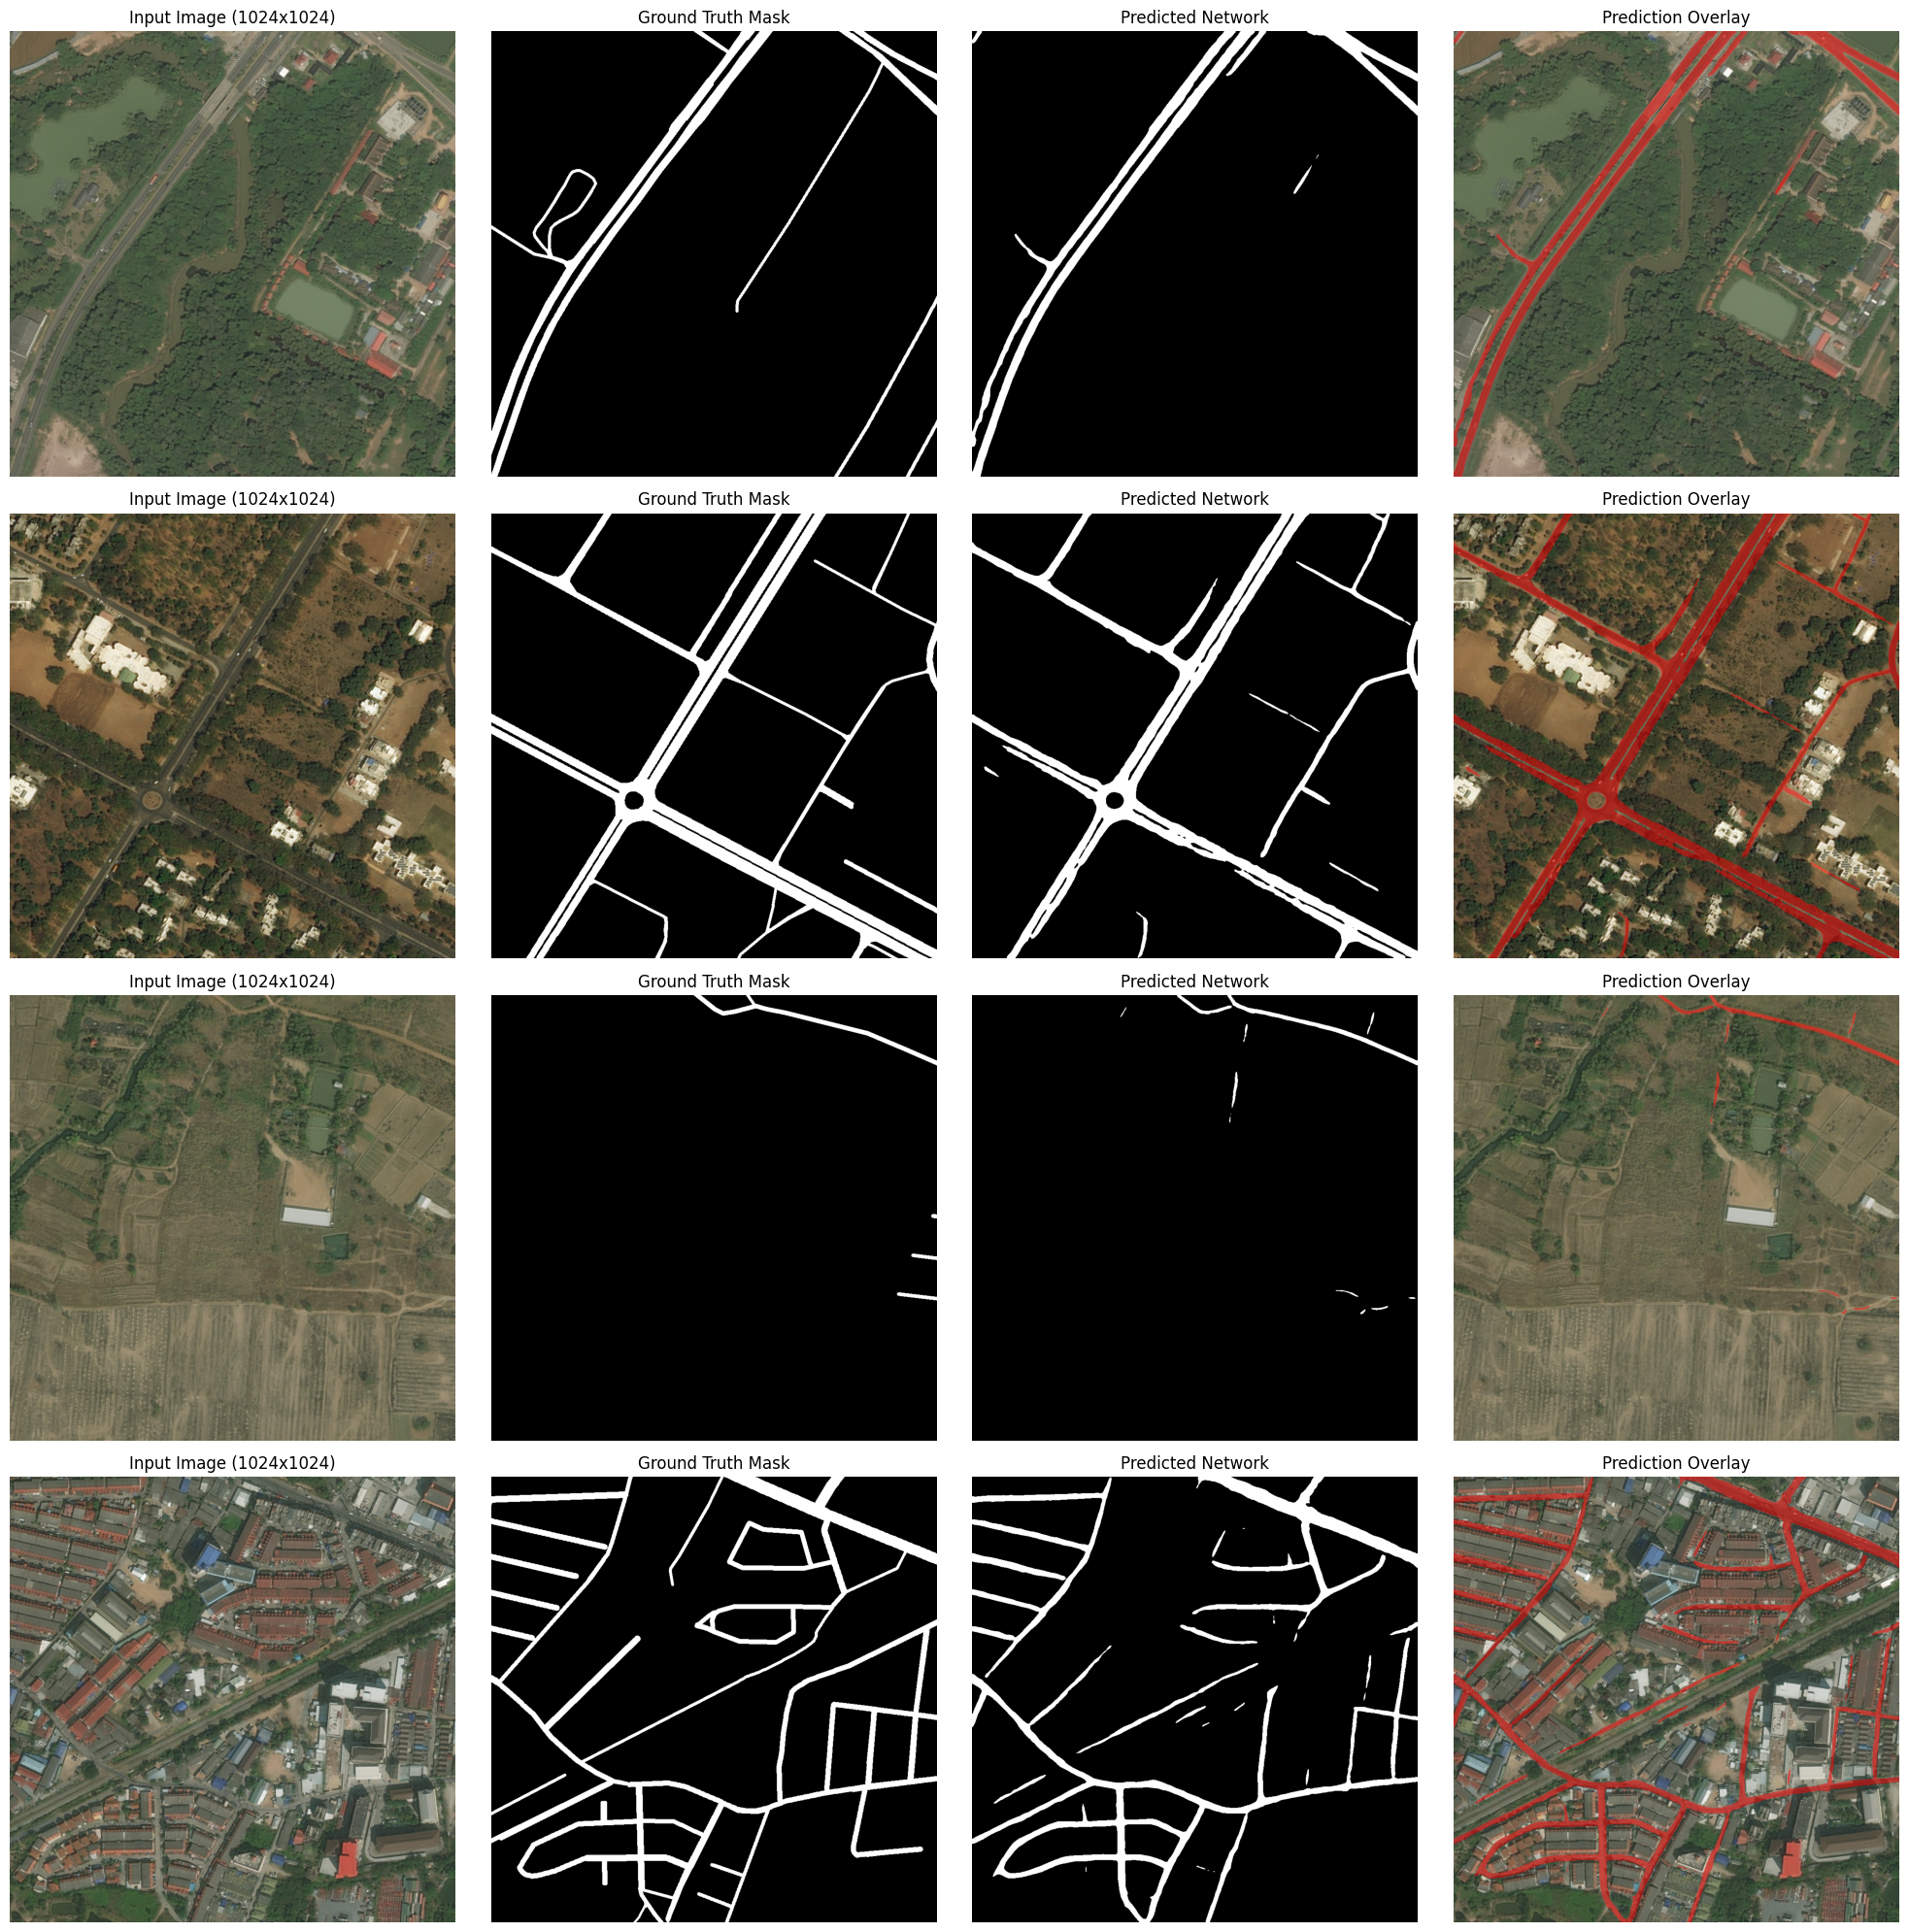

In [9]:
# ==========================================
# 5. MAIN EXECUTION GRAPH
# ==========================================
def main(train_dnet=False):
    print("Initializing File Paths...")
    all_sat_images = sorted(glob.glob(os.path.join(TRAIN_DIR, "*_sat.jpg")))
    if not all_sat_images:
        raise FileNotFoundError("No satellite images found. Verify Kaggle paths.")
        
    train_paths, val_paths = train_test_split(all_sat_images, test_size=0.2, random_state=42)
    
    print("Building Data Pipelines...")
    train_dataset = build_dataset(train_paths, training=True)
    val_dataset = build_dataset(val_paths, training=False)
    
    print("Compiling Architecture...")
    # Because we did not specify fixed sizes in Input(shape=(None, None, 3)), 
    # the exact same model instance can run 256x256 crops for training 
    # and 1024x1024 full images for evaluation.
    model = build_dlinknet_resnet50()
    
    # Using Adam with a low learning rate for staged fine-tuning of the ResNet
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    
    model.compile(
        optimizer=optimizer,
        loss=BCEDiceLoss(bce_weight=1.0, dice_weight=1.0),
        metrics=[tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)]
    )
    
    # Setup Callbacks
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            SAVE_PATH, 
            monitor='val_binary_io_u', 
            mode='max', 
            save_best_only=True, 
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_binary_io_u', 
            mode='max', 
            patience=20, 
            restore_best_weights=True
        )
    ]
    print("Commencing Training Phase...")
    if train_dnet:
        model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            callbacks=callbacks
        )
    else:
        model=tf.keras.models.load_model("/kaggle/input/models/aneeshshastri/road-extraction-pretrained/keras/default/1/dlinknet_resnet50.keras",compile=False)
        
    # Model state is automatically restored to best weights by EarlyStopping
    evaluate_full_resolution(model, val_paths)
    visualize_predictions(model, val_paths, num_samples=4)

if __name__ == "__main__":

    main()